# HECO Monte Carlo sensitivity analysis — parallel, metrics only

This notebook runs independent Monte Carlo realizations with **four worker processes**. It retains only compact metric tables: no trajectory CSVs, GeoJSON, maps, plots, GIFs, or HTML files are generated.

The default experiment perturbs the spill origin using an isotropic bivariate Gaussian error. Diffusion-coefficient sampling is available but disabled by default. In `paired` mode, every perturbed run is compared with an unperturbed run using the same stochastic seed (common random numbers). This reduces random noise in the sensitivity comparison.


In [8]:
# Limit native-library threads: parallelism is managed by joblib processes.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from contextlib import redirect_stderr, redirect_stdout
from copy import deepcopy
from pathlib import Path
from tempfile import TemporaryDirectory
import hashlib
import io
import json
import math
import time

import numpy as np
import pandas as pd
import pyproj
import yaml
from IPython.display import display
from joblib import Parallel, delayed, parallel_backend
from shapely import wkb
from shapely.geometry import MultiPoint
from shapely.ops import transform as transform_geometry

import heco

print(f"HECO module: {Path(heco.__file__).resolve()}")
print(f"Available logical CPUs: {os.cpu_count()}")

HECO module: /Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/heco.py
Available logical CPUs: 8


## Experiment configuration

`ORIGIN_SIGMA_KM` must represent a documented one-standard-deviation location uncertainty; replace the illustrative value below with the uncertainty justified for the study. `REFERENCE_MODE = "paired"` is recommended for origin sensitivity. Use `"fixed"` only when computing time is more important than separating parameter effects from stochastic diffusion noise; fixed mode requires approximately half as many HECO executions.

In [9]:
# Input configuration already present in the repository.
BASE_CONFIG_PATH = Path("sa_2_3/input_yaml_files/sa_2_3_test_0.yaml")
OUTPUT_DIR = Path("montecarlo_results")

N_REALIZATIONS = 100 #validation test 10 realizations, full text 100 realizations
N_WORKERS = 4
BATCH_SIZE = 8                 # Save a checkpoint after every eight realizations.
MASTER_SEED = 20260721
REFERENCE_MODE = "paired"    # Allowed values: "paired" or "fixed".
REFERENCE_SEED = 20260722      # Used only in fixed-reference mode.

# Monte Carlo input distributions.
ORIGIN_SIGMA_KM = 2.0          # Replace with documented 1-sigma location error.
SAMPLE_DIFFUSION = False
DIFFUSION_CV = 0.20            # Coefficient of variation if sampling is enabled.

PROJECTED_CRS = "EPSG:32632"  # UTM 32N for approximately 10.5 E, 40.5 N.
INTERPOLATED_VELOCITY = False

if N_WORKERS != 4:
    raise ValueError("This notebook is configured for N_WORKERS = 4.")
if REFERENCE_MODE not in {"paired", "fixed"}:
    raise ValueError("REFERENCE_MODE must be 'paired' or 'fixed'.")
if N_REALIZATIONS < 1 or BATCH_SIZE < 1:
    raise ValueError("N_REALIZATIONS and BATCH_SIZE must be positive.")
if ORIGIN_SIGMA_KM < 0 or DIFFUSION_CV < 0:
    raise ValueError("Uncertainty parameters cannot be negative.")

In [10]:
# Load and validate the base configuration once.
BASE_CONFIG_PATH = BASE_CONFIG_PATH.resolve()
if not BASE_CONFIG_PATH.exists():
    raise FileNotFoundError(f"Base configuration not found: {BASE_CONFIG_PATH}")

with BASE_CONFIG_PATH.open() as stream:
    BASE_CONFIG = yaml.safe_load(stream)

if not isinstance(BASE_CONFIG, dict) or "input" not in BASE_CONFIG:
    raise ValueError("The YAML file must contain an 'input' mapping.")

BASE_INPUT = BASE_CONFIG["input"]
required_keys = {
    "dataset_file_name", "lat0", "lon0", "sim_diffusion_coeff",
    "sim_duration_h", "sim_particles", "sim_timedelta_s",
    "spill_release_duration_h", "time0", "volume_spilled_m3",
}
missing = required_keys.difference(BASE_INPUT)
if missing:
    raise ValueError(f"Base configuration is missing: {sorted(missing)}")

# Parallel Monte Carlo should use a local forcing dataset, not repeated API calls.
dataset_path = Path(BASE_INPUT["dataset_file_name"])
if not dataset_path.is_absolute():
    candidates = [Path.cwd() / dataset_path, BASE_CONFIG_PATH.parent / dataset_path]
    dataset_path = next((path for path in candidates if path.exists()), candidates[0])
if not dataset_path.exists():
    raise FileNotFoundError(f"Local forcing dataset not found: {dataset_path}")
BASE_INPUT["dataset_file_name"] = str(dataset_path.resolve())

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Base configuration: {BASE_CONFIG_PATH}")
print(f"Forcing dataset: {dataset_path.resolve()} ({dataset_path.stat().st_size / 2**20:.1f} MiB)")
print(f"Reference mode: {REFERENCE_MODE}; workers: {N_WORKERS}; realizations: {N_REALIZATIONS}")

Base configuration: /Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/sa_2_3/input_yaml_files/sa_2_3_test_0.yaml
Forcing dataset: /Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/HECO_TEST.nc (176.4 MiB)
Reference mode: paired; workers: 4; realizations: 100


## In-memory geometry and metric helpers

Only the final simulated timestamp is converted to a convex hull. The trajectory DataFrame is then deleted without being written to disk.

In [11]:
GEOD = pyproj.Geod(ellps="WGS84")


def final_convex_hull(output):
    """Return the WGS84 convex hull for the latest output timestamp."""
    required = {"time", "lat", "lon"}
    missing = required.difference(output.columns)
    if missing:
        raise ValueError(f"HECO output is missing columns: {sorted(missing)}")
    if output.empty:
        raise ValueError("HECO returned an empty trajectory.")

    timestamps = pd.to_datetime(output["time"])
    final_rows = output.loc[timestamps == timestamps.max(), ["lon", "lat"]]
    points = [(float(lon), float(lat)) for lon, lat in final_rows.itertuples(index=False)]
    if len(points) < 3:
        raise ValueError(f"Final timestamp has only {len(points)} points; at least three are required.")
    hull = MultiPoint(points).convex_hull
    if hull.is_empty or hull.area == 0:
        raise ValueError("Final convex hull is empty or has zero area.")
    return hull


def compute_metrics(observed_wgs84, simulated_wgs84, projected_crs=PROJECTED_CRS):
    """Compute SRA, CI, Jaccard, Dice and scalar diagnostics in metres."""
    transformer = pyproj.Transformer.from_crs(
        "EPSG:4326", projected_crs, always_xy=True
    )
    observed = transform_geometry(transformer.transform, observed_wgs84)
    simulated = transform_geometry(transformer.transform, simulated_wgs84)
    if not observed.is_valid:
        observed = observed.buffer(0)
    if not simulated.is_valid:
        simulated = simulated.buffer(0)

    intersection_area = observed.intersection(simulated).area
    union_area = observed.union(simulated).area
    observed_area = observed.area
    simulated_area = simulated.area
    centroid_distance = observed.centroid.distance(simulated.centroid)
    minx, miny, maxx, maxy = observed.bounds
    box_diagonal = math.hypot(maxx - minx, maxy - miny)

    return {
        "SRA": intersection_area / observed_area if observed_area > 0 else np.nan,
        "CI": centroid_distance / box_diagonal if box_diagonal > 0 else np.nan,
        "Jaccard": intersection_area / union_area if union_area > 0 else np.nan,
        "DICE": (2 * intersection_area / (observed_area + simulated_area)
                 if observed_area + simulated_area > 0 else np.nan),
        "reference_area_km2": observed_area / 1e6,
        "simulation_area_km2": simulated_area / 1e6,
        "intersection_area_km2": intersection_area / 1e6,
        "union_area_km2": union_area / 1e6,
        "centroid_distance_km": centroid_distance / 1e3,
        "reference_box_diagonal_km": box_diagonal / 1e3,
    }


def run_heco_from_mapping(config, seed, temporary_directory, filename):
    """Execute HECO from a temporary YAML file and suppress verbose worker logs."""
    config_path = Path(temporary_directory) / filename
    with config_path.open("w") as stream:
        yaml.safe_dump(config, stream, sort_keys=False)

    captured_output = io.StringIO()
    with redirect_stdout(captured_output), redirect_stderr(captured_output):
        output = heco.run(
            str(config_path),
            seed=int(seed),
            interpolated=INTERPOLATED_VELOCITY,
        )
    return output


def sample_configuration(parameter_seed):
    """Sample uncertain inputs and return a modified configuration plus metadata."""
    rng = np.random.default_rng(parameter_seed)
    config = deepcopy(BASE_CONFIG)
    inputs = config["input"]

    east_m = float(rng.normal(0, ORIGIN_SIGMA_KM * 1000))
    north_m = float(rng.normal(0, ORIGIN_SIGMA_KM * 1000))
    distance_m = math.hypot(east_m, north_m)
    azimuth_deg = math.degrees(math.atan2(east_m, north_m)) if distance_m else 0.0
    perturbed_lon, perturbed_lat, _ = GEOD.fwd(
        float(BASE_INPUT["lon0"]),
        float(BASE_INPUT["lat0"]),
        azimuth_deg,
        distance_m,
    )
    inputs["lat0"] = float(perturbed_lat)
    inputs["lon0"] = float(perturbed_lon)

    base_diffusion = float(BASE_INPUT["sim_diffusion_coeff"])
    if SAMPLE_DIFFUSION and DIFFUSION_CV > 0:
        sigma_log = math.sqrt(math.log1p(DIFFUSION_CV ** 2))
        mean_log = math.log(base_diffusion) - 0.5 * sigma_log ** 2
        sampled_diffusion = float(rng.lognormal(mean_log, sigma_log))
    else:
        sampled_diffusion = base_diffusion
    inputs["sim_diffusion_coeff"] = sampled_diffusion

    metadata = {
        "lat0": float(perturbed_lat),
        "lon0": float(perturbed_lon),
        "origin_east_km": east_m / 1000,
        "origin_north_km": north_m / 1000,
        "origin_distance_km": distance_m / 1000,
        "origin_azimuth_deg": azimuth_deg,
        "sim_diffusion_coeff": sampled_diffusion,
    }
    return config, metadata

## Reproducible task construction

Each realization receives separate parameter and simulation seeds derived from `MASTER_SEED`. Results are reproducible and independent of task completion order.

In [12]:
master_sequence = np.random.SeedSequence(MASTER_SEED)
realization_sequences = master_sequence.spawn(N_REALIZATIONS)
TASKS = []
for realization_id, realization_sequence in enumerate(realization_sequences):
    parameter_sequence, simulation_sequence = realization_sequence.spawn(2)
    parameter_seed = int(parameter_sequence.generate_state(1, dtype=np.uint32)[0])
    simulation_seed = int(simulation_sequence.generate_state(1, dtype=np.uint32)[0])
    TASKS.append({
        "realization_id": realization_id,
        "parameter_seed": parameter_seed,
        "simulation_seed": simulation_seed,
    })

experiment_settings = {
    "base_config": str(BASE_CONFIG_PATH),
    "master_seed": MASTER_SEED,
    "n_realizations": N_REALIZATIONS,
    "reference_mode": REFERENCE_MODE,
    "reference_seed": REFERENCE_SEED,
    "origin_sigma_km": ORIGIN_SIGMA_KM,
    "sample_diffusion": SAMPLE_DIFFUSION,
    "diffusion_cv": DIFFUSION_CV,
    "projected_crs": PROJECTED_CRS,
    "interpolated_velocity": INTERPOLATED_VELOCITY,
}
EXPERIMENT_ID = hashlib.sha256(
    json.dumps(experiment_settings, sort_keys=True).encode()
).hexdigest()[:12]
RESULT_PATH = OUTPUT_DIR / f"montecarlo_metrics_{EXPERIMENT_ID}.csv"
SUMMARY_PATH = OUTPUT_DIR / f"montecarlo_summary_{EXPERIMENT_ID}.csv"
SENSITIVITY_PATH = OUTPUT_DIR / f"montecarlo_spearman_{EXPERIMENT_ID}.csv"

# Fixed mode computes one reference footprint. Paired mode computes one
# seed-matched reference inside every worker. WKB keeps process transfer compact.
FIXED_REFERENCE_WKB = None
if REFERENCE_MODE == "fixed":
    with TemporaryDirectory(prefix="heco_mc_reference_") as temporary_directory:
        reference_output = run_heco_from_mapping(
            deepcopy(BASE_CONFIG), REFERENCE_SEED, temporary_directory, "reference.yaml"
        )
        FIXED_REFERENCE_WKB = wkb.dumps(final_convex_hull(reference_output))
        del reference_output


def run_realization(task, fixed_reference_wkb=None):
    """Run one Monte Carlo realization and return one flat data record."""
    started = time.perf_counter()
    record = dict(task)
    try:
        perturbed_config, sampled = sample_configuration(task["parameter_seed"])
        record.update(sampled)

        with TemporaryDirectory(prefix=f"heco_mc_{task['realization_id']:05d}_") as temporary_directory:
            if REFERENCE_MODE == "paired":
                reference_output = run_heco_from_mapping(
                    deepcopy(BASE_CONFIG),
                    task["simulation_seed"],
                    temporary_directory,
                    "reference.yaml",
                )
                reference_hull = final_convex_hull(reference_output)
                del reference_output
            else:
                if fixed_reference_wkb is None:
                    raise ValueError("Fixed reference geometry was not supplied.")
                reference_hull = wkb.loads(fixed_reference_wkb)

            simulation_output = run_heco_from_mapping(
                perturbed_config,
                task["simulation_seed"],
                temporary_directory,
                "perturbed.yaml",
            )
            simulation_hull = final_convex_hull(simulation_output)
            del simulation_output

        record.update(compute_metrics(reference_hull, simulation_hull))
        record["status"] = "ok"
        record["error"] = ""
    except Exception as error:
        record["status"] = "error"
        record["error"] = f"{type(error).__name__}: {error}"

    record["runtime_seconds"] = time.perf_counter() - started
    record["reference_mode"] = REFERENCE_MODE
    record["experiment_id"] = EXPERIMENT_ID
    return record

print(f"Experiment ID: {EXPERIMENT_ID}")
print(f"Checkpoint/result file: {RESULT_PATH}")

Experiment ID: f1047bd7b058
Checkpoint/result file: montecarlo_results/montecarlo_metrics_f1047bd7b058.csv


## Execute four-worker Monte Carlo batches

The result CSV is atomically updated after every batch. Re-running this cell resumes successful realizations and retries failed ones. Four processes may collectively require more than four times the memory of one HECO run because every process opens the forcing dataset.

In [13]:
if RESULT_PATH.exists():
    accumulated = pd.read_csv(RESULT_PATH)
else:
    accumulated = pd.DataFrame()

completed_ids = set()
if not accumulated.empty and {"realization_id", "status"}.issubset(accumulated.columns):
    completed_ids = set(
        accumulated.loc[accumulated["status"] == "ok", "realization_id"].astype(int)
    )

pending_tasks = [task for task in TASKS if task["realization_id"] not in completed_ids]
print(f"Completed: {len(completed_ids)}; pending: {len(pending_tasks)}")

for batch_start in range(0, len(pending_tasks), BATCH_SIZE):
    batch = pending_tasks[batch_start:batch_start + BATCH_SIZE]
    with parallel_backend("loky", inner_max_num_threads=1):
        batch_records = Parallel(
            n_jobs=N_WORKERS,
            batch_size=1,
            verbose=5,
        )(
            delayed(run_realization)(task, FIXED_REFERENCE_WKB)
            for task in batch
        )

    batch_frame = pd.DataFrame.from_records(batch_records)
    batch_ids = set(batch_frame["realization_id"].astype(int))
    if not accumulated.empty and "realization_id" in accumulated.columns:
        accumulated = accumulated.loc[
            ~accumulated["realization_id"].astype(int).isin(batch_ids)
        ]
    accumulated = pd.concat([accumulated, batch_frame], ignore_index=True)
    accumulated = accumulated.sort_values("realization_id").reset_index(drop=True)

    temporary_result_path = RESULT_PATH.with_suffix(".tmp.csv")
    accumulated.to_csv(temporary_result_path, index=False)
    os.replace(temporary_result_path, RESULT_PATH)

    ok_count = int((accumulated["status"] == "ok").sum())
    error_count = int((accumulated["status"] == "error").sum())
    print(f"Checkpoint: {ok_count} successful, {error_count} failed -> {RESULT_PATH}")

results = pd.read_csv(RESULT_PATH).sort_values("realization_id").reset_index(drop=True)
print(results["status"].value_counts(dropna=False))
results.head()

Completed: 0; pending: 100


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   3 out of   8 | elapsed:  4.6min remaining:  7.6min
[Parallel(n_jobs=4)]: Done   5 out of   8 | elapsed:  8.3min remaining:  5.0min
[Parallel(n_jobs=4)]: Done   8 out of   8 | elapsed:  8.7min finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Checkpoint: 8 successful, 0 failed -> montecarlo_results/montecarlo_metrics_f1047bd7b058.csv


[Parallel(n_jobs=4)]: Done   3 out of   8 | elapsed:  3.9min remaining:  6.5min
[Parallel(n_jobs=4)]: Done   5 out of   8 | elapsed:  8.0min remaining:  4.8min
[Parallel(n_jobs=4)]: Done   8 out of   8 | elapsed:  8.0min finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Checkpoint: 16 successful, 0 failed -> montecarlo_results/montecarlo_metrics_f1047bd7b058.csv


...

[Parallel(n_jobs=4)]: Done   3 out of   8 | elapsed:  3.8min remaining:  6.4min
[Parallel(n_jobs=4)]: Done   5 out of   8 | elapsed:  7.9min remaining:  4.7min
[Parallel(n_jobs=4)]: Done   8 out of   8 | elapsed:  7.9min finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Checkpoint: 96 successful, 0 failed -> montecarlo_results/montecarlo_metrics_f1047bd7b058.csv


[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:  4.1min remaining:  4.1min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  4.1min finished


Checkpoint: 100 successful, 0 failed -> montecarlo_results/montecarlo_metrics_f1047bd7b058.csv
status
ok    100
Name: count, dtype: int64


,realization_id,parameter_seed,simulation_seed,lat0,lon0,origin_east_km,origin_north_km,origin_distance_km,origin_azimuth_deg,sim_diffusion_coeff,...,simulation_area_km2,intersection_area_km2,union_area_km2,centroid_distance_km,reference_box_diagonal_km,status,error,runtime_seconds,reference_mode,experiment_id
0,0,204894643,261703470,40.545024,10.486725,-1.124506,4.999777,5.124674,-12.675546,10.0,...,75.945397,0.000000,141.699639,15.893811,20.169085,ok,NaN,244.299365,paired,f1047bd7b058
1,1,1832766025,1795031612,40.500111,10.464057,-3.046781,0.012957,3.046809,-89.756345,10.0,...,75.155573,44.213635,112.003101,6.652253,21.975227,ok,NaN,242.689537,paired,f1047bd7b058
2,2,3455814263,3368106838,40.474506,10.470103,-2.535288,-2.830534,3.799949,-138.149432,10.0,...,72.569369,44.691381,87.605838,3.987604,19.130457,ok,NaN,250.562981,paired,f1047bd7b058
3,3,3666280429,666201667,40.514422,10.506355,0.538563,1.601550,1.689678,18.586572,10.0,...,98.811499,69.625760,117.182809,4.495845,24.058110,ok,NaN,248.863753,paired,f1047bd7b058
4,4,2212294546,2243757921,40.521536,10.498565,-0.121585,2.391484,2.394573,-2.910463,10.0,...,79.172542,33.359794,123.077629,8.333103,19.366495,ok,NaN,254.948612,paired,f1047bd7b058


## Compact numerical summary

This cell exports descriptive uncertainty intervals and Spearman rank associations. These are screening diagnostics, not variance-based Sobol indices.

In [14]:
successful = results.loc[results["status"] == "ok"].copy()
failed = results.loc[results["status"] != "ok", ["realization_id", "error"]].copy()

metric_columns = [
    "SRA", "CI", "Jaccard", "DICE",
    "simulation_area_km2", "centroid_distance_km",
]
if successful.empty:
    raise RuntimeError("No successful realizations. Inspect the failure table below.")

summary_records = []
for metric in metric_columns:
    values = successful[metric].dropna()
    count = int(values.size)
    standard_deviation = float(values.std(ddof=1)) if count > 1 else np.nan
    standard_error = standard_deviation / math.sqrt(count) if count > 1 else np.nan
    summary_records.append({
        "metric": metric,
        "n": count,
        "mean": float(values.mean()),
        "standard_deviation": standard_deviation,
        "standard_error": standard_error,
        "mean_ci95_low": float(values.mean() - 1.96 * standard_error) if count > 1 else np.nan,
        "mean_ci95_high": float(values.mean() + 1.96 * standard_error) if count > 1 else np.nan,
        "median": float(values.median()),
        "q025": float(values.quantile(0.025)),
        "q975": float(values.quantile(0.975)),
    })

summary = pd.DataFrame.from_records(summary_records)
summary.to_csv(SUMMARY_PATH, index=False)

input_columns = ["origin_east_km", "origin_north_km", "origin_distance_km"]
if SAMPLE_DIFFUSION:
    input_columns.append("sim_diffusion_coeff")
spearman = successful[input_columns + metric_columns].corr(method="spearman").loc[
    input_columns, metric_columns
]
spearman.to_csv(SENSITIVITY_PATH)

print(f"Successful realizations: {len(successful)}/{N_REALIZATIONS}")
print(f"Mean worker runtime: {successful['runtime_seconds'].mean():.1f} s")
print(f"Summary: {SUMMARY_PATH}")
print(f"Spearman screening: {SENSITIVITY_PATH}")
display(summary)
display(spearman)
if not failed.empty:
    display(failed)

Successful realizations: 100/100
Mean worker runtime: 235.7 s
Summary: montecarlo_results/montecarlo_summary_f1047bd7b058.csv
Spearman screening: montecarlo_results/montecarlo_spearman_f1047bd7b058.csv


,metric,n,mean,standard_deviation,standard_error,mean_ci95_low,mean_ci95_high,median,q025,q975
0,SRA,100,0.554150,0.287752,0.028775,0.497751,0.610550,0.637069,0.000000,0.929646
1,CI,100,0.339484,0.250013,0.025001,0.290481,0.388486,0.303766,0.029632,0.862930
2,Jaccard,100,0.409552,0.258704,0.025870,0.358846,0.460258,0.427362,0.000000,0.868807
3,DICE,100,0.530952,0.280167,0.028017,0.476039,0.585865,0.598810,0.000000,0.929792
4,simulation_area_km2,100,70.413389,12.261079,1.226108,68.010217,72.816560,69.290859,49.882876,94.857617
5,centroid_distance_km,100,6.482859,4.451193,0.445119,5.610426,7.355293,5.673348,0.587825,16.051108


,SRA,CI,Jaccard,DICE,simulation_area_km2,centroid_distance_km
origin_east_km,0.078241,0.003540,0.058737,0.058737,0.092385,-0.014425
origin_north_km,-0.278565,0.179550,-0.241395,-0.241395,-0.326613,0.168929
origin_distance_km,-0.730029,0.683816,-0.744251,-0.744251,0.007429,0.701422


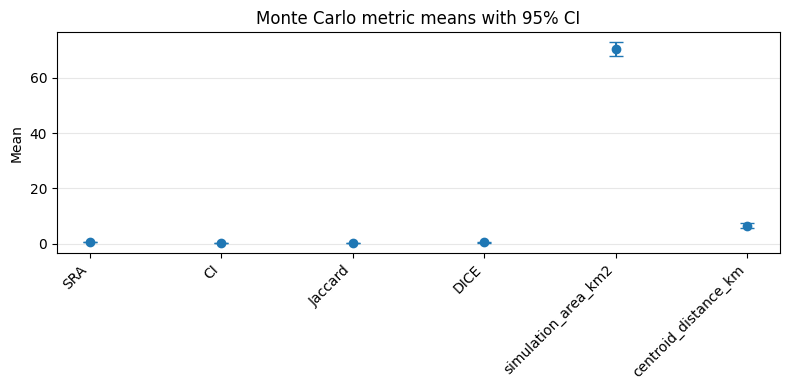

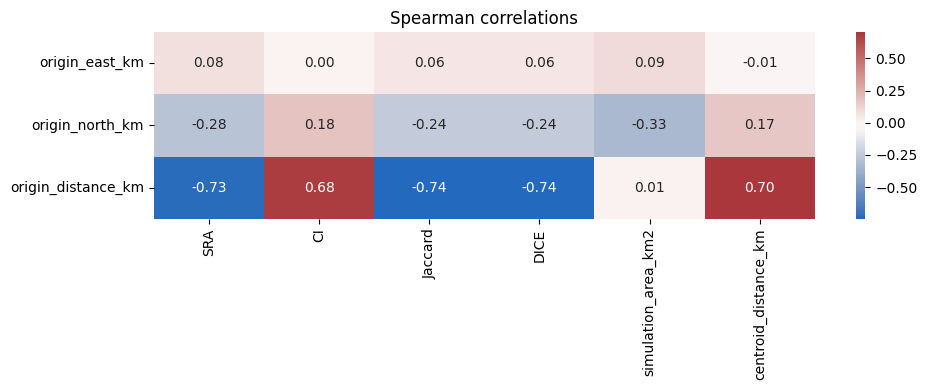

In [2]:
# Read the summary and spearman CSVs and plot them
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

summary_path = 'montecarlo_results/montecarlo_summary_f1047bd7b058.csv'
spearman_path = 'montecarlo_results/montecarlo_spearman_f1047bd7b058.csv'
summary = pd.read_csv(summary_path)

spearman = pd.read_csv(spearman_path, index_col=0)
# Error-bar plot of metric means with 95% CI
metrics = summary['metric'].astype(str)
means = summary['mean'].values
ci_low = summary['mean_ci95_low'].values
ci_high = summary['mean_ci95_high'].values
yerr_lower = means - ci_low
yerr_upper = ci_high - means
plt.figure(figsize=(8, 4))
plt.errorbar(metrics, means, yerr=[yerr_lower, yerr_upper], fmt='o', capsize=5, color='C0')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean')
plt.title('Monte Carlo metric means with 95% CI')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Spearman heatmap (seaborn if available, fallback to imshow)\n",
try:
    import seaborn as sns
    plt.figure(figsize=(10, 4))
    sns.heatmap(spearman, annot=True, fmt='.2f', cmap='vlag')
    plt.title('Spearman correlations')
    plt.tight_layout()
    plt.show()
except Exception:
    plt.figure(figsize=(10, 4))
    im = plt.imshow(spearman.values, cmap='vlag', aspect='auto')
    plt.xticks(range(len(spearman.columns)), spearman.columns, rotation=45, ha='right')
    plt.yticks(range(len(spearman.index)), spearman.index)
    plt.colorbar(im)
    plt.title('Spearman correlations (imshow)')
    plt.tight_layout()
    plt.show()
    
    # Print brief diagnostics\n",
    print(f'Summary rows: {len(summary)}; Spearman shape: {spearman.shape}')
    display(summary)
